In [1]:
# Load packages
from costs_benefits_ssp.cb_calculate import CostBenefits
import pandas as pd
import os
import pathlib
import numpy as np

In [2]:
##---- Define Directories ----##
SCRIPT_DIR_PATH = os.getcwd()
PARENT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
OUTPUT_CB_PATH = os.path.join(SCRIPT_DIR_PATH, "out")
CONFIG_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "cb_config_files")
RUN_OUTPUT_DIR_PATH = os.path.join(PARENT_DIR_PATH, "ssp_run_output")
RUN_ID = "sisepuede_results_run_sisepuede_run_2026-04-10T16;34;22.155007"
RUN_DIR_PATH = os.path.join(RUN_OUTPUT_DIR_PATH, RUN_ID )   
DIF_OUTPUT_FILE = os.path.join(PARENT_DIR_PATH,"tableau/data")

In [3]:
RUN_DIR_PATH

'/Users/alexa/Projects/ssp_libya/ssp_modeling/ssp_run_output/sisepuede_results_run_sisepuede_run_2026-04-10T16;34;22.155007'

In [4]:
# Make sure output directory exists
os.makedirs(OUTPUT_CB_PATH, exist_ok=True)

In [5]:
## Load the data
ssp_data = pd.read_csv(os.path.join(RUN_DIR_PATH, "decomposed_ssp_output.csv"))
att_primary = pd.read_csv(os.path.join(RUN_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"))
att_strategy = pd.read_csv(os.path.join(RUN_DIR_PATH, "ATTRIBUTE_STRATEGY.csv"))
print(f"Loaded ssp_data with {ssp_data.shape[0]} rows and {ssp_data.shape[1]} columns")
print(f"Loaded att_primary with {att_primary.shape[0]} rows and {att_primary.shape[1]} columns")
print(f"Loaded att_strategy with {att_strategy.shape[0]} rows and {att_strategy.shape[1]} columns")

Loaded ssp_data with 112 rows and 4107 columns
Loaded att_primary with 4 rows and 4 columns
Loaded att_strategy with 77 rows and 6 columns


In [6]:
att_strategy.head()

,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
0,0,BASE,Strategy TX:BASE,NaN,TX:BASE,1
1,1000,AGRC:DEC_CH4_RICE,Singleton - Default Value - AGRC: Improve rice...,NaN,TX:AGRC:DEC_CH4_RICE,0
2,1001,AGRC:DEC_EXPORTS,Singleton - Default Value - AGRC: Decrease Exp...,NaN,TX:AGRC:DEC_EXPORTS,0
3,1002,AGRC:DEC_LOSSES_SUPPLY_CHAIN,Singleton - Default Value - AGRC: Reduce suppl...,NaN,TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN,0
4,1003,AGRC:INC_CONSERVATION_AGRICULTURE,Singleton - Default Value - AGRC: Expand conse...,NaN,TX:AGRC:INC_CONSERVATION_AGRICULTURE,0


In [7]:
att_strategy.tail()

,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
72,6001,PFLO:INC_IND_CCS,Singleton - Default Value - PFLO: Industrial c...,NaN,TX:PFLO:INC_IND_CCS,0
73,6002,PFLO:ALL,All Actions,All actions (unique by transformer),TX:AGRC:DEC_CH4_RICE|TX:AGRC:DEC_EXPORTS|TX:AG...,0
74,6003,PFLO:BAU,BAU,BAU,TX:WASO:INC_ANAEROBIC_AND_COMPOST_STRATEGY_BAU...,0
75,6004,PFLO:UNCONDITIONAL,Unconditional,Unconditional,TX:FGTV:INC_FLARE_STRATEGY_UNCONDITIONAL|TX:IN...,0
76,6005,PFLO:CONDITIONAL,Conditional,Conditional,TX:INEN:INC_EFFICIENCY_PRODUCTION_STRATEGY_CON...,0


In [8]:
## Define base strategy
strategy_code_base = "PFLO:BAU"

In [9]:
# Check if strategy_code_base exists in att_strategy
if strategy_code_base not in att_strategy['strategy_code'].values:
    raise ValueError(f"Base strategy code '{strategy_code_base}' not found in att_strategy.")

In [10]:
## Instantiate an object of the CostBenefits class
cb = CostBenefits(ssp_data, att_primary, att_strategy, strategy_code_base)

The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTr

In [11]:
# Once the excel file has been updated, we can reload it to update the cost factors database
cb.load_cb_parameters(os.path.join(CONFIG_DIR_PATH, "cb_config_params.xlsx"))

Cargamos configuración de archivo excel
Se actualizó la base de datos


In [12]:
# Compute System Costs
results_system = cb.compute_system_cost_for_all_strategies(verbose=False)


************************************
*Strategy : BASE (0/3)
************************************


************************************
*Strategy : PFLO:UNCONDITIONAL (1/3)
************************************


************************************
*Strategy : PFLO:CONDITIONAL (2/3)
************************************



In [13]:
# Compute Technical Costs
results_tx = cb.compute_technical_cost_for_all_strategies(verbose=False)


************************************
*Strategy : BASE (0/3)
************************************

The Strategy BASE hasn't technical costs

************************************
*Strategy : PFLO:UNCONDITIONAL (1/3)
************************************

La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost


/opt/anaconda3/envs/ssp_libya_env_3/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1067: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_output['variable_value_baseline'] = 0
/opt/anaconda3/envs/ssp_libya_env_3/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1070: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_output['variable_value_pathway'] = data_merged["difference_value"]



************************************
*Strategy : PFLO:CONDITIONAL (2/3)
************************************

La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transform

/opt/anaconda3/envs/ssp_libya_env_3/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1067: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_output['variable_value_baseline'] = 0
/opt/anaconda3/envs/ssp_libya_env_3/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1070: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_output['variable_value_pathway'] = data_merged["difference_value"]


La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost


In [14]:
# Combine results
results_all = pd.concat([results_system, results_tx], ignore_index = True)

In [15]:
#-------------POST PROCESS SIMULATION RESULTS---------------
# Post process interactions among strategies that affect the same variables
results_all_pp = cb.cb_process_interactions(results_all)

# SHIFT any stray costs incurred from 2015 to 2025 to 2025 and 2035
results_all_pp_shifted = cb.cb_shift_costs(results_all_pp)


Resolving Interactions in SCOE :  
No interactions, skipping... BASE
Resolving Interactions in INEN :  
No interactions, skipping... BASE
Resolving Interactions in SCOE : TX:SCOE:INC_EFFICIENCY_APPLIANCE, TX:SCOE:DEC_DEMAND_HEAT 
Resolving Interactions in INEN : TX:INEN:INC_EFFICIENCY_ENERGY 
Resolving Interactions in SCOE : TX:SCOE:INC_EFFICIENCY_APPLIANCE, TX:SCOE:DEC_DEMAND_HEAT 
Resolving Interactions in INEN : TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:INC_EFFICIENCY_ENERGY 


/opt/anaconda3/envs/ssp_libya_env_3/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:660: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_pre2025["variable"] = res_pre2025["variable"] + "_shifted" + (res_pre2025["time_period"]+SSP_GLOBAL_TIME_PERIOD_0).astype(str)#create a new variable so they can be recognized as shifted costs
/opt/anaconda3/envs/ssp_libya_env_3/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:661: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_pre2025["t

In [16]:
results_all_pp_shifted

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value
0,BASE,0,libya,8,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0
1,BASE,0,libya,9,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0
2,BASE,0,libya,10,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0
3,BASE,0,libya,11,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0
4,BASE,0,libya,12,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0
...,...,...,...,...,...,...,...,...,...,...
18145,PFLO:CONDITIONAL,0,libya,19,energy_consumption_inen_total,114.774759,114.774759,0.0,cb:inen:technical_cost:fuel_switch:all_shifted...,0.0
18146,PFLO:CONDITIONAL,0,libya,18,energy_consumption_inen_total,111.014192,111.014192,0.0,cb:inen:technical_savings:fuel_switch:all_shif...,-0.0
18147,PFLO:CONDITIONAL,0,libya,19,energy_consumption_inen_total,114.774759,114.774759,0.0,cb:inen:technical_savings:fuel_switch:all_shif...,-0.0
18148,PFLO:CONDITIONAL,0,libya,18,energy_consumption_inen_total,131.536266,131.536266,0.0,cb:inen:technical_cost:efficiency:X_shifted2023,0.0


In [17]:
results_all_pp_shifted.strategy_code.unique()

array(['BASE', 'PFLO:UNCONDITIONAL', 'PFLO:CONDITIONAL'], dtype=object)

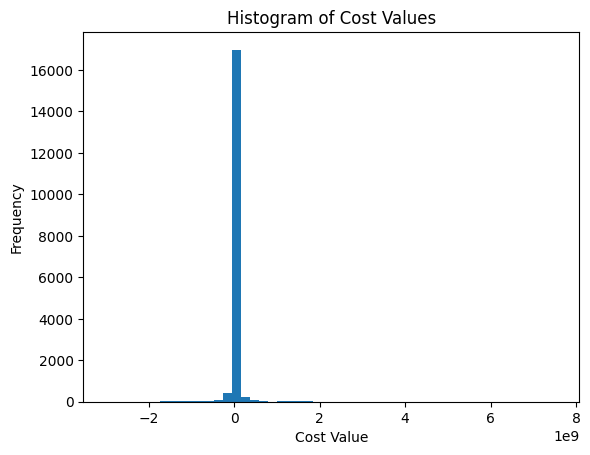

In [18]:
import matplotlib.pyplot as plt
plt.hist(results_all_pp_shifted.value, bins=50)
plt.title('Histogram of Cost Values')
plt.xlabel('Cost Value')
plt.ylabel('Frequency')
plt.show()

## Check for NaNs and Infs and DF Cleaning

In [19]:
# check nans
results_all_pp_shifted.value.isna().any()

np.False_

In [20]:
# check -inf or inf values
results_all_pp_shifted.value.isin([float('inf'), float('-inf')]).any()

np.False_

## Reshape to load into tableau

In [21]:
# --- Read cost-benefit data ---
cb_data = results_all_pp_shifted.copy()

# Split 'variable' into components: name, sector, cb_type, item_1, item_2
# (Assumes exactly 5 colon-separated parts; if there are more colons inside the last field,
# they will be kept in item_2 thanks to n=4)
cb_chars = cb_data["variable"].astype(str).str.split(":", n=4, expand=True)
cb_chars.columns = ["name", "sector", "cb_type", "item_1", "item_2"]
cb_data = pd.concat([cb_data, cb_chars], axis=1)

In [22]:
cb_data.head()

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,name,sector,cb_type,item_1,item_2
0,BASE,0,libya,8,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices
1,BASE,0,libya,9,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices
2,BASE,0,libya,10,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices
3,BASE,0,libya,11,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices
4,BASE,0,libya,12,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices


In [23]:
# Scale value from USD to billions (divide by 1e9)
if "value" in cb_data.columns:
    cb_data["value"] = cb_data["value"] / 1e9

# --- Remove "shifted" entries ---
# Remove rows where item_2 contains "shifted"
cb_data = cb_data[~cb_data["item_2"].astype(str).str.contains("shifted", na=False)]

# Remove any remaining rows where variable contains "shifted2"
cb_data = cb_data[~cb_data["variable"].astype(str).str.contains("shifted2", na=False)]

# --- Add Year column (Year = time_period + 2015) ---
cb_data["Year"] = cb_data["time_period"] + 2015

**This Section Needs Manual Tunnning**

In [24]:
cb_data.strategy_code.unique()

array(['BASE', 'PFLO:UNCONDITIONAL', 'PFLO:CONDITIONAL'], dtype=object)

In [25]:
# Harmonize strategy name changes with a single mapping (no duplicate replacements)
strategy_name_map = {
    "PFLO:BAU": "Business as Usual",
    "PFLO:UNCONDITIONAL": "Unconditional",
    "PFLO:CONDITIONAL": "Conditional",
}

cb_data["strategy"] = (
    cb_data["strategy_code"].astype(str).map(strategy_name_map).fillna(cb_data["strategy_code"])
)
print(cb_data["strategy"].unique())


['BASE' 'Unconditional' 'Conditional']


In [26]:
# --- Strategy ID mapping based on strategy_code ---
def map_strategy_id(code: str):
    if code == "BASE":
        return 0
    if code == "PFLO:BAU":
        return 6003
    if code == "PFLO:UNCONDITIONAL":
        return 6004
    if code == "PFLO:CONDITIONAL":
        return 6005
    return code  # keep original if not matched

cb_data["strategy_id"] = cb_data["strategy_code"].astype(str).map(map_strategy_id)

In [27]:
ssp_data.primary_id.unique()

array([    0, 74074, 75075, 76076])

In [28]:
ssp_data

,primary_id,region,time_period,area_agrc_crops_bevs_and_spices,area_agrc_crops_cereals,area_agrc_crops_fibers,area_agrc_crops_fruits,area_agrc_crops_herbs_and_other_perennial_crops,area_agrc_crops_nuts,area_agrc_crops_other_annual,...,yf_agrc_herbs_and_other_perennial_crops_tonne_ha,yf_agrc_nuts_tonne_ha,yf_agrc_other_annual_tonne_ha,yf_agrc_other_woody_perennial_tonne_ha,yf_agrc_pulses_tonne_ha,yf_agrc_rice_tonne_ha,yf_agrc_sugar_cane_tonne_ha,yf_agrc_tubers_tonne_ha,yf_agrc_vegetables_and_vines_tonne_ha,yf_lndu_supremum_pastures_tonne_per_ha
0,0,libya,8,0,4.035087e+06,0,3.088256e+06,0,737827.582324,2.579297e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81
1,0,libya,9,0,4.186683e+06,0,3.204280e+06,0,765547.399674,2.676199e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81
2,0,libya,10,0,4.306798e+06,0,3.296210e+06,0,787510.787871,2.752979e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81
3,0,libya,11,0,4.401839e+06,0,3.368950e+06,0,804889.323997,2.813731e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81
4,0,libya,12,0,4.476885e+06,0,3.426386e+06,0,818611.693756,2.861702e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,76076,libya,31,0,4.649217e+06,0,3.558280e+06,0,850123.029351,2.971859e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81
108,76076,libya,32,0,4.640740e+06,0,3.551793e+06,0,848572.984640,2.966440e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81
109,76076,libya,33,0,4.631906e+06,0,3.545032e+06,0,846957.746210,2.960794e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81
110,76076,libya,34,0,4.622765e+06,0,3.538036e+06,0,845286.236255,2.954950e+06,...,2,0.5,0,0,0.5,0,0,17,20,92.81


In [29]:
def map_primary_id(code: str):
    if code == "BASE":
        return 0
    if code == "PFLO:BAU":
        return 74074
    if code == "PFLO:UNCONDITIONAL":
        return 75075
    if code == "PFLO:CONDITIONAL":
        return 76076
    return code  # keep original if not matched

cb_data["primary_id"] = cb_data["strategy_code"].astype(str).map(map_primary_id)


**Manual Tunning Ends Here**

In [30]:
# --- Create ids (variable:strategy_id) ---
cb_data["ids"] = cb_data["variable"].astype(str) + ":" + cb_data["strategy_id"].astype(str)

In [31]:
cb_data.head()

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,name,sector,cb_type,item_1,item_2,Year,strategy,strategy_id,primary_id,ids
0,BASE,0,libya,8,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2023,BASE,0,0,cb:agrc:crop_value:crops_produced:bevs_and_spi...
1,BASE,0,libya,9,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2024,BASE,0,0,cb:agrc:crop_value:crops_produced:bevs_and_spi...
2,BASE,0,libya,10,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2025,BASE,0,0,cb:agrc:crop_value:crops_produced:bevs_and_spi...
3,BASE,0,libya,11,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2026,BASE,0,0,cb:agrc:crop_value:crops_produced:bevs_and_spi...
4,BASE,0,libya,12,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2027,BASE,0,0,cb:agrc:crop_value:crops_produced:bevs_and_spi...


In [32]:
cb_data.strategy.unique()

array(['BASE', 'Unconditional', 'Conditional'], dtype=object)

In [33]:
cb_data.strategy_code.unique()

array(['BASE', 'PFLO:UNCONDITIONAL', 'PFLO:CONDITIONAL'], dtype=object)

In [34]:
# --- Read GDP and merge ---
# Keep only needed columns
gdp = ssp_data.loc[:, ["primary_id", "time_period", "gdp_mmm_usd"]]
gdp.head(100)

,primary_id,time_period,gdp_mmm_usd
0,0,8,101.162039
1,0,9,105.576742
2,0,10,107.688276
3,0,11,109.842042
4,0,12,112.038883
...,...,...,...
95,76076,19,128.697459
96,76076,20,131.271408
97,76076,21,133.896836
98,76076,22,136.574773


In [35]:
gdp[gdp['primary_id']== 76076]

,primary_id,time_period,gdp_mmm_usd
84,76076,8,101.162039
85,76076,9,105.576742
86,76076,10,107.688276
87,76076,11,109.842042
88,76076,12,112.038883
89,76076,13,114.279660
90,76076,14,116.565254
91,76076,15,118.896559
92,76076,16,121.274490
93,76076,17,123.699980


In [36]:
# Merge cb_data with gdp on primary_id and time_period
cb_data = cb_data.merge(gdp, on=["primary_id", "time_period"], how="left")
cb_data

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,...,sector,cb_type,item_1,item_2,Year,strategy,strategy_id,primary_id,ids,gdp_mmm_usd
0,BASE,0,libya,8,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2023,BASE,0,0,cb:agrc:crop_value:crops_produced:bevs_and_spi...,101.162039
1,BASE,0,libya,9,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2024,BASE,0,0,cb:agrc:crop_value:crops_produced:bevs_and_spi...,105.576742
2,BASE,0,libya,10,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2025,BASE,0,0,cb:agrc:crop_value:crops_produced:bevs_and_spi...,107.688276
3,BASE,0,libya,11,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2026,BASE,0,0,cb:agrc:crop_value:crops_produced:bevs_and_spi...,109.842042
4,BASE,0,libya,12,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2027,BASE,0,0,cb:agrc:crop_value:crops_produced:bevs_and_spi...,112.038883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16935,PFLO:CONDITIONAL,0,libya,31,energy_consumption_inen_total,137.189871,81.201079,-55.988791,cb:inen:technical_cost:efficiency:X,-0.559888,...,inen,technical_cost,efficiency,X,2046,Conditional,6005,76076,cb:inen:technical_cost:efficiency:X:6005,163.219496
16936,PFLO:CONDITIONAL,0,libya,32,energy_consumption_inen_total,136.769424,80.257951,-56.511473,cb:inen:technical_cost:efficiency:X,-0.565115,...,inen,technical_cost,efficiency,X,2047,Conditional,6005,76076,cb:inen:technical_cost:efficiency:X:6005,166.483886
16937,PFLO:CONDITIONAL,0,libya,33,energy_consumption_inen_total,136.346327,79.483449,-56.862877,cb:inen:technical_cost:efficiency:X,-0.568629,...,inen,technical_cost,efficiency,X,2048,Conditional,6005,76076,cb:inen:technical_cost:efficiency:X:6005,169.813564
16938,PFLO:CONDITIONAL,0,libya,34,energy_consumption_inen_total,135.920657,78.873071,-57.047586,cb:inen:technical_cost:efficiency:X,-0.570476,...,inen,technical_cost,efficiency,X,2049,Conditional,6005,76076,cb:inen:technical_cost:efficiency:X:6005,173.209835


In [37]:
cb_data.isna().sum()

strategy_code                0
future_id                    0
region                       0
time_period                  0
difference_variable          0
variable_value_baseline      0
variable_value_pathway     168
difference_value             0
variable                     0
value                        0
name                         0
sector                       0
cb_type                      0
item_1                       0
item_2                     364
Year                         0
strategy                     0
strategy_id                  0
primary_id                   0
ids                          0
gdp_mmm_usd                  0
dtype: int64

## Save

In [38]:
cb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16940 entries, 0 to 16939
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   strategy_code            16940 non-null  object 
 1   future_id                16940 non-null  int64  
 2   region                   16940 non-null  object 
 3   time_period              16940 non-null  int64  
 4   difference_variable      16940 non-null  object 
 5   variable_value_baseline  16940 non-null  float64
 6   variable_value_pathway   16772 non-null  float64
 7   difference_value         16940 non-null  float64
 8   variable                 16940 non-null  object 
 9   value                    16940 non-null  float64
 10  name                     16940 non-null  object 
 11  sector                   16940 non-null  object 
 12  cb_type                  16940 non-null  object 
 13  item_1                   16940 non-null  object 
 14  item_2                

In [39]:
cb_data["Year"]

0        2023
1        2024
2        2025
3        2026
4        2027
         ... 
16935    2046
16936    2047
16937    2048
16938    2049
16939    2050
Name: Year, Length: 16940, dtype: int64

In [40]:
# Use .loc and avoid chained indexing; cast Year to int to be robust
selection = cb_data.loc[(cb_data["Year"] == 2027)]

In [41]:
cb_data.loc[
    (cb_data["variable"] == "cb:entc:technical_cost:electricity:capex") &
    (cb_data["value"] > 0),
    "value"
] = 0


In [42]:
# ensure no positive technical costs for electricity capex
mask = cb_data["variable"].astype(str).str.contains("cb:entc:technical_cost:electricity:capex", na=False)
cb_data.loc[mask, "value"] = -cb_data.loc[mask, "value"].abs()

# quick check
cb_data[mask]["value"].describe()

count    84.000000
mean     -0.667664
std       0.793341
min      -3.003135
25%      -1.143014
50%      -0.493442
75%       0.000000
max      -0.000000
Name: value, dtype: float64

In [43]:
cb_data[cb_data.variable == "cb:entc:technical_cost:electricity:capex"].describe()


,future_id,time_period,variable_value_baseline,variable_value_pathway,difference_value,value,Year,strategy_id,primary_id,gdp_mmm_usd
count,84.0,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,0.0,21.500000,330.354678,997.053037,666.698359,-0.667664,2036.500000,4003.000000,50383.666667,136.882164
std,0.0,8.126263,553.624151,936.410277,794.206516,0.793341,8.126263,2847.548919,35842.965807,22.117109
min,0.0,8.000000,0.000000,0.000000,-76.299357,-3.003135,2023.000000,0.000000,0.000000,101.162039
25%,0.0,14.750000,176.982613,195.184894,0.000000,-1.143014,2029.750000,0.000000,0.000000,118.313732
50%,0.0,21.500000,207.133761,827.565326,493.442457,-0.493442,2036.500000,6004.000000,75075.000000,135.235805
75%,0.0,28.250000,251.728880,1658.058668,1143.013703,0.000000,2043.250000,6005.000000,76076.000000,154.574404
max,0.0,35.000000,2495.925970,3260.333502,3003.134504,-0.000000,2050.000000,6005.000000,76076.000000,176.674032


In [44]:
cb_data.to_csv(os.path.join(DIF_OUTPUT_FILE,"cb_data.csv"), index = False)

In [45]:
os.path.join(DIF_OUTPUT_FILE,"cb_data.csv")

'/Users/alexa/Projects/ssp_libya/ssp_modeling/tableau/data/cb_data.csv'